<a href="https://colab.research.google.com/github/kledihaxhimali/Data-Science-Projects/blob/Password-Prediction/PredictPassword.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA COLLECTION

In [63]:
from sqlite3.dbapi2 import connect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
con = sqlite3.connect("password_data.sqlite")
data= pd.read_sql_query("SELECT * FROM Users", con)#return a data frame
import warnings
from warnings import filterwarnings
filterwarnings("ignore")

In [64]:
data.shape

(100000, 3)

# DATA CLEANING

In [65]:
data.columns


Index(['index', 'password', 'strength'], dtype='object')

In [66]:
data.drop(["index"], axis=1, inplace=True)
data.head(4)

,password,strength
0,zxe870819,1
1,xw46454nr23l,1
2,soporte13,1
3,accounts6000webhost.com,2


In [67]:
data.duplicated().sum()

np.int64(0)

In [68]:
data.isnull().any()

,0
password,False
strength,False


In [69]:
data.isnull().any().sum()

np.int64(0)

In [70]:
data.dtypes


,0
password,object
strength,int64


In [71]:
data["strength"].unique()

array([1, 2, 0])

# DATA ANALYSIS

Semantic Analysis

In [72]:
data["password"]

,password
0,zxe870819
1,xw46454nr23l
2,soporte13
3,accounts6000webhost.com
4,c443balg
...,...
99995,obejofi215
99996,fmiopvxb64
99997,czvrbun38
99998,mymyxe430


In [73]:
data["password"][0]
type(data["password"][0])

str

In [74]:
data["password"].str.isnumeric()

,password
0,False
1,False
2,False
3,False
4,False
...,...
99995,False
99996,False
99997,False
99998,False


In [75]:
data[data["password"].str.isnumeric()]

,password,strength
12280,943801,0
14992,12345,0
20958,147856,0
21671,140290,0
23269,123987,0
28569,1233214,0
31329,0159456,0
32574,363761,0
37855,4524344,0
43648,5521597,0


In [76]:
data[data["password"].str.isnumeric()].shape

(26, 2)

In [77]:
data[data["password"].str.isupper()].shape

(1506, 2)

In [78]:
data[data["password"].str.isalpha()].shape

(50, 2)

In [79]:
data[data["password"].str.isalnum()].shape

(97203, 2)

In [80]:
data[data["password"].str.istitle()] #first letter capital

,password,strength
64,Hisanthoshjasika0,2
242,Therockrockbottom72,2
338,1A2S3D4F,1
367,13269123A,1
526,Csicskarozsika1,2
...,...,...
99168,1053815198M,1
99192,Alfranx05122023,2
99375,Kensington1956,2
99590,V13000993J,1


In [81]:
import string
string.punctuation

def find_semantics(row):
  for char in row:
    if char in string.punctuation:
      return 1
    else:
      pass
data["password"].apply(find_semantics)==1

,password
0,False
1,False
2,False
3,True
4,False
...,...
99995,False
99996,False
99997,False
99998,False


In [82]:
data[data["password"].apply(find_semantics)==1]

,password,strength
3,accounts6000webhost.com,2
68,12463773800+,1
98,p.r.c.d.g.,1
145,cita-cita,1
180,karolina.susnina0U,2
...,...,...
99748,maiselis.com,1
99845,hosting4meze!@#,2
99954,semista_bakung15,2
99980,halflife2010!LEB,2


# FEATURE ENGINEERING

In [83]:
data["password"][0]

'zxe870819'

In [84]:
len(data["password"][0])

9

In [85]:
data['length'] = data["password"].str.len()

In [86]:
password = 'Shan99'

In [87]:
len([char for char in password if char.islower()])

3

In [88]:
def freq_lowercase(row):
  return len([char for char in row if char.islower()])/len(row)

In [89]:
def freq_uppercase(row):
  return len([char for char in row if char.isupper()])/len(row)

In [90]:
def freq_numerical_case(row):
  return len([char for char in row if char.isdigit()])/len(row)

In [91]:
def freq_special_case(row):
   special_chars= []
   for char in row:
    if not char.isalpha() and not char .isdigit():
      special_chars.append(char)
   return len(special_chars)/len(row)


In [92]:
data["lower_freq"] = np.round(data["password"].apply(freq_lowercase), 3)
data["upper_freq"] = np.round(data["password"].apply(freq_uppercase), 3 )
data["digit_freq"] = np.round(data["password"].apply(freq_numerical_case), 3)
data["special_freq"] = np.round(data["password"].apply(freq_special_case),3)
data.head(4)

,password,strength,length,lower_freq,upper_freq,digit_freq,special_freq
0,zxe870819,1,9,0.333,0.0,0.667,0.000
1,xw46454nr23l,1,12,0.417,0.0,0.583,0.000
2,soporte13,1,9,0.778,0.0,0.222,0.000
3,accounts6000webhost.com,2,23,0.783,0.0,0.174,0.043


Performing Descriptive Statistics

In [93]:
data[['length', 'strength']].groupby(['strength']).agg(["min", 'max', 'mean', 'median'])

length                       
            min  max       mean median
strength                              
0             1    7   6.550947    7.0
1             8   13   9.611074    9.0
2            14  220  15.953421   16.0

In [94]:
cols = ['length', 'lower_freq', 'upper_freq', 'digit_freq', 'special_freq']
for col in cols:
  print(col)
  print(data[['strength', col]].groupby(['strength']).agg(["min", 'max', 'mean', 'median']))
  print('/n')

length
         length                       
            min  max       mean median
strength                              
0             1    7   6.550947    7.0
1             8   13   9.611074    9.0
2            14  220  15.953421   16.0
/n
lower_freq
         lower_freq                        
                min    max      mean median
strength                                   
0               0.0  1.000  0.708050  0.714
1               0.0  0.923  0.630067  0.667
2               0.0  0.917  0.424679  0.400
/n
upper_freq
         upper_freq                        
                min    max      mean median
strength                                   
0               0.0  1.000  0.012872  0.000
1               0.0  0.923  0.007915  0.000
2               0.0  0.889  0.367633  0.429
/n
digit_freq
         digit_freq                        
                min    max      mean median
strength                                   
0               0.0  1.000  0.275383  0.286
1            

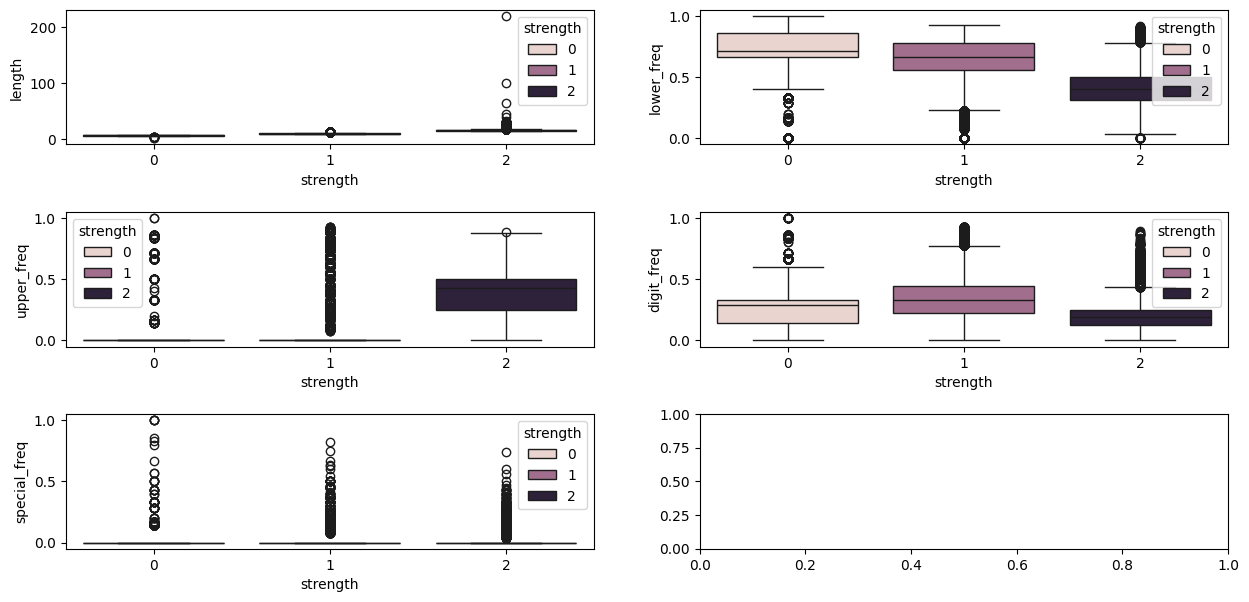

In [95]:
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6))= plt.subplots(3,2, figsize=(15,7))
sns.boxplot(x='strength', y='length', hue="strength", ax=ax1, data=data)
sns.boxplot(x='strength', y='lower_freq', hue="strength", ax=ax2, data=data)
sns.boxplot(x='strength', y='upper_freq', hue="strength", ax=ax3, data=data)
sns.boxplot(x='strength', y='digit_freq', hue="strength", ax=ax4, data=data)
sns.boxplot(x='strength', y='special_freq', hue="strength", ax=ax5, data=data)
plt.subplots_adjust(hspace=0.5)

Feature Importance

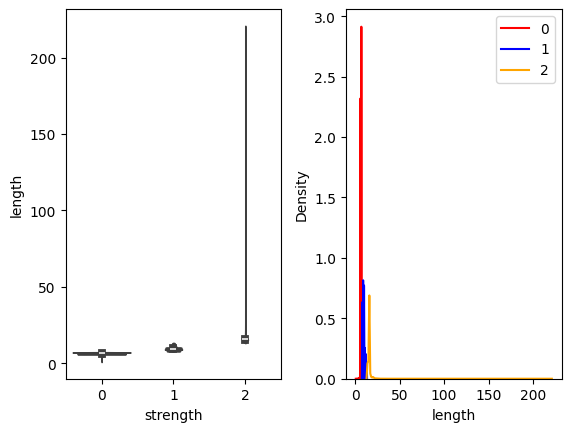

In [96]:
def get_dist(data, feature):
    plt.subplot(1,2,1)
    sns.violinplot(x= 'strength', y=feature, data=data)
    plt.subplot(1,2,2)
    sns.distplot(data[data['strength']==0][feature], color='red', label='0', hist=False)
    sns.distplot(data[data['strength']==1][feature], color='blue', label='1', hist=False)
    sns.distplot(data[data['strength']==2][feature], color='orange', label='2', hist=False)
    plt.subplots_adjust(wspace=0.3)
    plt.legend()
    plt.show()
get_dist(data, 'length')

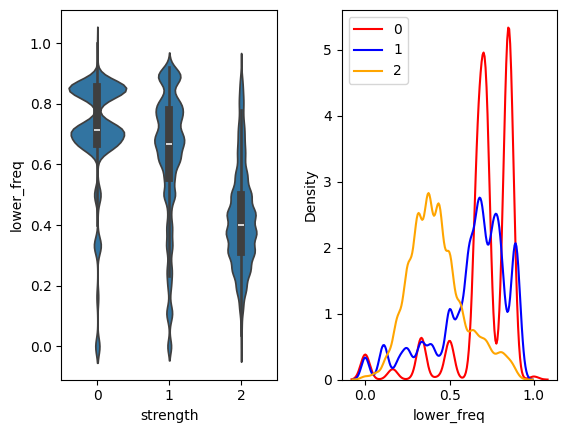

In [97]:
get_dist(data, 'lower_freq')

TF-IDF

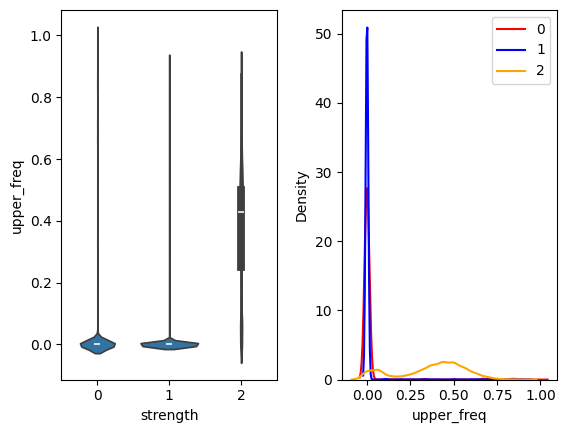

In [98]:
get_dist(data, 'upper_freq')

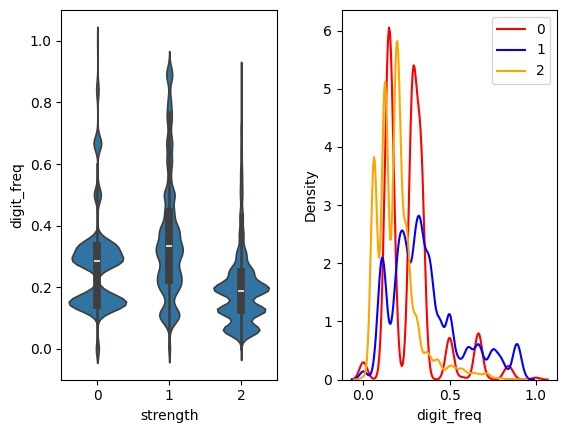

In [99]:
get_dist(data, 'digit_freq')

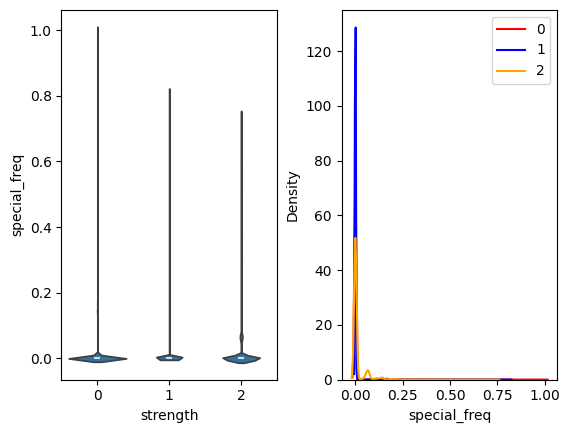

In [100]:
get_dist(data, 'special_freq')

In [101]:
data.head(4)

,password,strength,length,lower_freq,upper_freq,digit_freq,special_freq
0,zxe870819,1,9,0.333,0.0,0.667,0.000
1,xw46454nr23l,1,12,0.417,0.0,0.583,0.000
2,soporte13,1,9,0.778,0.0,0.222,0.000
3,accounts6000webhost.com,2,23,0.783,0.0,0.174,0.043


In [102]:
dataframe= data.sample(frac=1)
dataframe

,password,strength,length,lower_freq,upper_freq,digit_freq,special_freq
24008,rcijhpo362,1,10,0.700,0.000,0.300,0.00
53500,skudero76,1,9,0.778,0.000,0.222,0.00
81863,16.02.12,1,8,0.000,0.000,0.750,0.25
61271,suksesi123,1,10,0.700,0.000,0.300,0.00
41805,144poXImefikAf,2,14,0.571,0.214,0.214,0.00
...,...,...,...,...,...,...,...
31226,nivled123,1,9,0.667,0.000,0.333,0.00
65692,kb011b,0,6,0.500,0.000,0.500,0.00
76211,ishida1,0,7,0.857,0.000,0.143,0.00
9123,128bxtk22,1,9,0.444,0.000,0.556,0.00


In [103]:
x = list(dataframe['password'])

In [104]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer= TfidfVectorizer(analyzer= 'char')
X=vectorizer. fit_transform(x)
X.shape

(100000, 99)

In [105]:
X.toarray()[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.26036509, 0.29161003, 0.        ,
       0.        , 0.34155967, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.33946092,
       0.        , 0.        , 0.        , 0.        , 0.34979366,
       0.26308684, 0.37605207, 0.        , 0.        , 0.        ,
       0.        , 0.26630515, 0.357812  , 0.        , 0.28869287,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [106]:
len(vectorizer.get_feature_names_out())

99

In [107]:
df2= pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
df2

,,,,,,,,,!,#,...,ñ,ó,õ,ö,÷,ú,ü,ý,þ,›
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
99996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
99997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
99998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


we have converted text to vector

# Model Building

In [108]:
dataframe.columns


Index(['password', 'strength', 'length', 'lower_freq', 'upper_freq',
       'digit_freq', 'special_freq'],
      dtype='object')

In [109]:
df2['lenght']= dataframe['length']
df2['lower_freq']= dataframe['lower_freq']
df2

,,,,,,,,,!,#,...,õ,ö,÷,ú,ü,ý,þ,›,lenght,lower_freq
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,0.333
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12,0.417
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,0.778
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23,0.783
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8,0.625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10,0.700
99996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10,0.800
99997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,0.778
99998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,0.667


In [110]:
#X independent data/  y dependent data
from sklearn.model_selection import train_test_split
x= df2
y= dataframe['strength']
X_train, X_test, y_train, y_test= train_test_split(x, y, test_size=0.2)
X_train.shape

(80000, 101)

In [111]:
y_train.shape

(80000,)

In [112]:
from sklearn.linear_model import LogisticRegression
model= LogisticRegression(multi_class='multinomial')
model.fit(X_train, y_train)
y_pred= model.predict(X_test)

In [113]:
y_pred

array([1, 1, 1, ..., 1, 1, 1])

In [114]:
from collections import Counter
Counter(y_pred)

Counter({np.int64(1): 16510, np.int64(2): 1970, np.int64(0): 1520})

In [129]:
def predict():
  password= input('Enter a password: ')
  sample_array=np.array([password])
  sample_matrix= vectorizer.transform(sample_array)

  length_pass= len(password)
  length_normalized_lowercase= len([char for char in password if char.islower()])/len(password)

  new_matrix2= np.append(sample_matrix.toarray(), (length_pass, length_normalized_lowercase)).reshape(1,101)
  result= model.predict(new_matrix2)

  if result ==0:
    print('Password is weak')
  elif result==1:
    print('Password is medium')
  else:
    print('Password is strong')
predict()

Enter a password: asasas
Password is weak


In [133]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
accuracy_score(y_test, y_pred)

0.8045

In [134]:
confusion_matrix(y_test, y_pred)

array([[  794,  1915,     2],
       [  669, 13699,   371],
       [   57,   896,  1597]])

In [135]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.52      0.29      0.38      2711
           1       0.83      0.93      0.88     14739
           2       0.81      0.63      0.71      2550

    accuracy                           0.80     20000
   macro avg       0.72      0.62      0.65     20000
weighted avg       0.79      0.80      0.79     20000

